# Rude Gestures — MLP Training

Train a lightweight MLP on 63-dimensional hand landmark features.

**Input**: 21 MediaPipe landmarks × (x, y, z) = 63 features  
**Output**: 7 gesture classes

> Run in Google Colab. Upload `data/raw/landmarks_augmented.csv` first (or mount your Drive).

In [1]:
# ── 0. Install dependencies (Colab only) ─────────────────────────────────────
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip install -q torch torchvision scikit-learn matplotlib seaborn pandas numpy

In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import copy
import pathlib
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [8]:
# ── 2. Load data ──────────────────────────────────────────────────────────────
# Change this path if needed
#CSV_PATH = pathlib.Path('../data/raw/landmarks_augmented.csv')

# If running in Colab, upload manually and set path:
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = pathlib.Path('/content/drive/MyDrive/landmarks_aug.csv')

df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df)} samples.')
print('Class distribution:')
print(df['label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 28135 samples.
Class distribution:
label
crossed_fingers    4390
thumbs_up          4125
ok_sign            3995
neutral            3970
middle_finger      3945
reversed_v         3915
corna              3795
Name: count, dtype: int64


In [9]:
# ── 3. Encode labels & split ──────────────────────────────────────────────────
CLASS_NAMES = [
    'middle_finger', 'reversed_v', 'thumbs_up', 'corna',
    'crossed_fingers', 'ok_sign', 'neutral'
]

le = LabelEncoder()
le.fit(CLASS_NAMES)              # deterministic order
y = le.transform(df['label'])

feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols].values.astype(np.float32)

# 70 / 15 / 15 stratified split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 19694 | Val: 4220 | Test: 4221


In [10]:
# ── 4. DataLoaders ────────────────────────────────────────────────────────────
def to_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)

In [11]:
# ── 5. Model architecture ─────────────────────────────────────────────────────
# Loss: CrossEntropyLoss — combines LogSoftmax + NLLLoss internally.
# The model outputs raw logits (no final softmax); CrossEntropyLoss handles that.
NUM_FEATURES = 63
NUM_CLASSES  = 7


class GestureMLP(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            )

        self.net = nn.Sequential(
            block(NUM_FEATURES, 256),   # ← new wider first layer
            block(256, 128),
            block(128, 64),
            block(64, 32),              # ← 4 hidden layers total
            nn.Linear(32, NUM_CLASSES),
        )

    def forward(self, x):
        return self.net(x)


model = GestureMLP().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

GestureMLP(
  (net): Sequential(
    (0): Sequential(
      (0): Linear(in_features=63, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
    )
    (3): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    

In [15]:
# ── 6. Training setup ─────────────────────────────────────────────────────────
EPOCHS       = 200
LR           = 1e-3
PATIENCE     = 15       # early stopping patience
CKPT_PATH    = pathlib.Path('/content/drive/MyDrive/best_model.pt')
CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=7
            )

In [16]:
# ── 7. Training loop ──────────────────────────────────────────────────────────
def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
no_improve    = 0
best_state    = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0
        torch.save({'model_state_dict': best_state}, CKPT_PATH)
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'Epoch {epoch:3d}/{EPOCHS}  '
            f'train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  '
            f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}'
        )

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
        break

# Reload best weights
model.load_state_dict(best_state)
print(f'\nBest validation loss: {best_val_loss:.4f}')

Epoch   1/200  train_loss=0.6675  train_acc=0.832  val_loss=0.1665  val_acc=0.954
Epoch  10/200  train_loss=0.1027  train_acc=0.971  val_loss=0.0563  val_acc=0.983
Epoch  20/200  train_loss=0.0764  train_acc=0.979  val_loss=0.0280  val_acc=0.992
Epoch  30/200  train_loss=0.0631  train_acc=0.982  val_loss=0.0243  val_acc=0.994
Epoch  40/200  train_loss=0.0512  train_acc=0.985  val_loss=0.0185  val_acc=0.995
Epoch  50/200  train_loss=0.0469  train_acc=0.986  val_loss=0.0134  val_acc=0.995
Epoch  60/200  train_loss=0.0409  train_acc=0.989  val_loss=0.0104  val_acc=0.997
Epoch  70/200  train_loss=0.0282  train_acc=0.992  val_loss=0.0080  val_acc=0.998
Epoch  80/200  train_loss=0.0243  train_acc=0.993  val_loss=0.0076  val_acc=0.998
Epoch  90/200  train_loss=0.0191  train_acc=0.995  val_loss=0.0046  val_acc=0.999
Epoch 100/200  train_loss=0.0130  train_acc=0.996  val_loss=0.0049  val_acc=0.999
Early stopping at epoch 103 (no improvement for 15 epochs).

Best validation loss: 0.0045


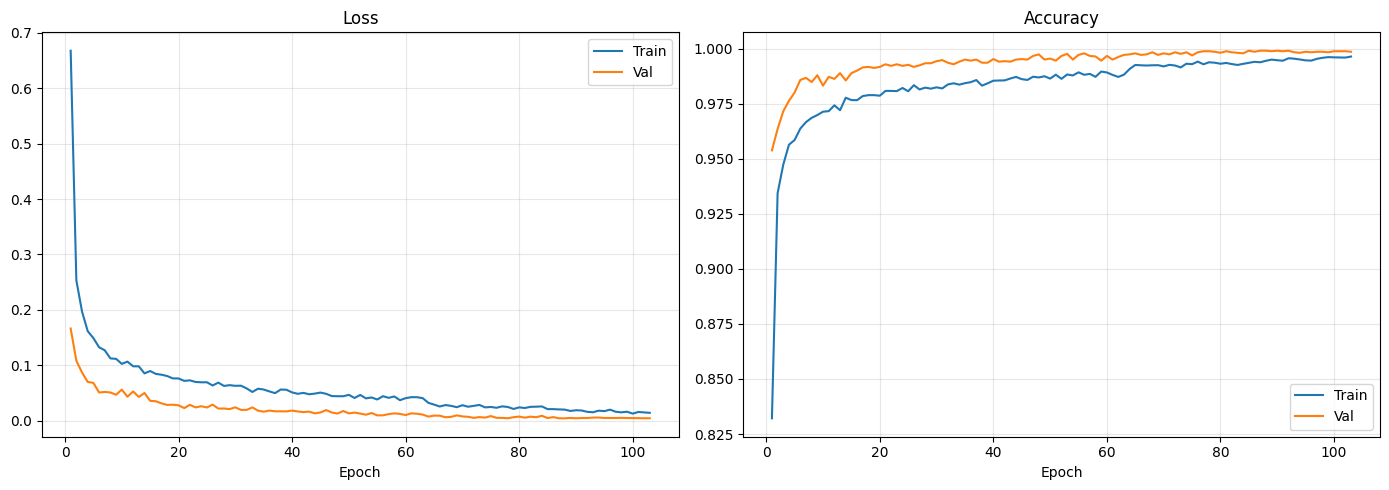

In [17]:
# ── 8. Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../model/training_curves.png', dpi=150)
plt.show()

In [18]:
# ── 9. Evaluation on test set ─────────────────────────────────────────────────
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = (all_preds == all_targets).mean()
print(f'Test accuracy: {test_acc:.4f}\n')

print(classification_report(
    all_targets, all_preds,
    target_names=le.classes_,
    digits=3
))

Test accuracy: 0.9972

                 precision    recall  f1-score   support

          corna      1.000     1.000     1.000       569
crossed_fingers      1.000     0.994     0.997       659
  middle_finger      0.997     0.998     0.997       592
        neutral      0.997     0.992     0.994       595
        ok_sign      0.988     0.998     0.993       600
     reversed_v      0.998     1.000     0.999       587
      thumbs_up      1.000     0.998     0.999       619

       accuracy                          0.997      4221
      macro avg      0.997     0.997     0.997      4221
   weighted avg      0.997     0.997     0.997      4221



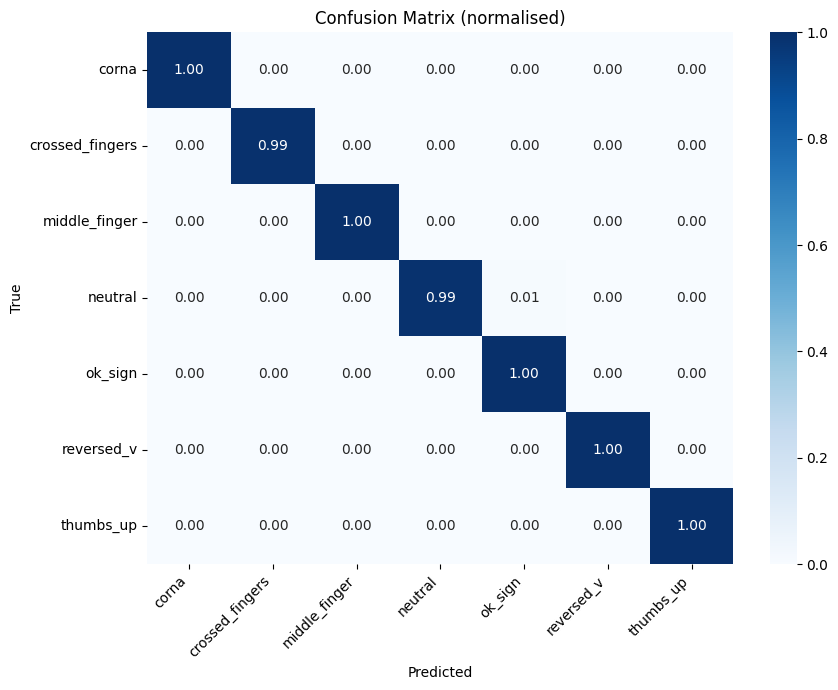

In [19]:
# ── 10. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (normalised)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png', dpi=150)
plt.show()

In [20]:
# ── 11. Export to ONNX (optional, run locally) ────────────────────────────────
# For ONNX export, run model/export_onnx.py from the command line:
#   python model/export_onnx.py --checkpoint model/best_model.pt
print('Model checkpoint saved to:', CKPT_PATH.resolve())
print('Run `python model/export_onnx.py` to export to ONNX.')

Model checkpoint saved to: /content/drive/MyDrive/best_model.pt
Run `python model/export_onnx.py` to export to ONNX.
